# Phase 2.4 — Power Curve Analysis

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path so we can import from src/
PROJECT_ROOT = Path("D:/Personal Projects/Enbridge Case Compettion")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from src.data.load_data import load_event, load_event_info, get_event_ids
from src.features.operating_conditions import (
    FEATURE_CATEGORIES,
    FEATURE_DESCRIPTIONS,
)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 9,
})

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Per-farm wind speed & power column selection
# ---------------------------------------------------------------------------
# Pick the primary measured wind speed and primary active power for each farm.
POWER_CURVE_COLS = {
    "A": {"wind_speed": "wind_speed_3_avg", "power": "power_29_avg"},
    "B": {"wind_speed": "wind_speed_61_avg", "power": "power_62_avg"},
    "C": {"wind_speed": "wind_speed_235_avg", "power": "power_6_avg"},
}

# Status type labels and color palette (consistent across all plots)
STATUS_LABELS = {
    0: "Normal",
    1: "Derated",
    2: "Idling",
    3: "Service",
    4: "Downtime",
    5: "Other",
}
STATUS_COLORS = {
    0: "#2196F3",  # blue
    1: "#FF9800",  # orange
    2: "#4CAF50",  # green
    3: "#9C27B0",  # purple
    4: "#F44336",  # red
    5: "#795548",  # brown
}

MAX_POINTS = 50_000  # cap scatter points per plot for performance

# Load event catalog
events_df = load_event_info()

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIGURES_DIR}")
print(f"Events loaded: {len(events_df)} rows")

Project root: D:\Personal Projects\Enbridge Case Compettion
Figures dir:  D:\Personal Projects\Enbridge Case Compettion\outputs\figures
Events loaded: 95 rows


The **power curve** (wind speed vs power output) is the fundamental performance indicator for wind turbines. Under normal operation, it follows a characteristic S-shape: zero output below cut-in speed (~3 m/s), a steep ramp through the cubic region, then a flat plateau at rated power until cut-out.

**Deviations from the expected curve indicate:**
- **Curtailment / derating** — the turbine is intentionally limited (points below the curve).
- **Faults** — mechanical or electrical issues cause power loss at a given wind speed.
- **Degradation** — gradual efficiency loss shifts the curve downward over time.

We color-code points by `status_type_id` to see how different operating modes populate the power curve.

In [2]:
def plot_power_curve(ax, df, farm_letter, title, sample_max=MAX_POINTS):
    """Scatter plot of wind speed vs power, colored by status_type_id.
    
    Parameters
    ----------
    ax : matplotlib Axes
    df : DataFrame with wind speed, power, and status_type_id columns
    farm_letter : str — "A", "B", or "C"
    title : str — subplot title
    sample_max : int — max points to plot (random sample if exceeded)
    """
    cols = POWER_CURVE_COLS[farm_letter]
    ws_col = cols["wind_speed"]
    pw_col = cols["power"]
    
    # Drop rows with NaN in the key columns
    plot_df = df[[ws_col, pw_col, "status_type_id"]].dropna()
    
    # Sample if too many points
    if len(plot_df) > sample_max:
        plot_df = plot_df.sample(n=sample_max, random_state=42)
    
    # Sort so that rarer status types are plotted on top (visible)
    status_counts = plot_df["status_type_id"].value_counts()
    plot_df = plot_df.copy()
    plot_df["_sort_order"] = plot_df["status_type_id"].map(
        lambda s: status_counts.get(s, 0)
    )
    plot_df = plot_df.sort_values("_sort_order", ascending=False)
    
    # Plot each status type separately for legend control
    present_statuses = sorted(plot_df["status_type_id"].unique())
    for status in present_statuses:
        mask = plot_df["status_type_id"] == status
        subset = plot_df[mask]
        ax.scatter(
            subset[ws_col],
            subset[pw_col],
            c=STATUS_COLORS.get(status, "#999999"),
            label=f"{STATUS_LABELS.get(status, f'Status {status}')} ({len(subset):,})",
            s=4,
            alpha=0.3,
            edgecolors="none",
            rasterized=True,
        )
    
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Power Output (normalized)")
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=7, markerscale=3, framealpha=0.9)
    ax.set_xlim(left=-0.5)
    ax.set_ylim(bottom=-0.05)


def get_event_description(farm_letter, event_id):
    """Return the event description string from the catalog, or 'N/A'."""
    row = events_df[
        (events_df["farm"] == farm_letter) & (events_df["event_id"] == event_id)
    ]
    if len(row) == 0:
        return "N/A"
    desc = row.iloc[0]["event_description"]
    if pd.isna(desc):
        return "Normal operation"
    return str(desc)


print("Plotting helpers defined.")

Plotting helpers defined.


## Farm A — Power Curves

Comparing a normal operation event against an anomaly event (generator bearing failure). The normal event should show a clean S-shaped power curve dominated by blue (Normal status) points, while the anomaly event may show scattered points from Downtime/Service status and possible power loss regions.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\power_curve_farm_a.png


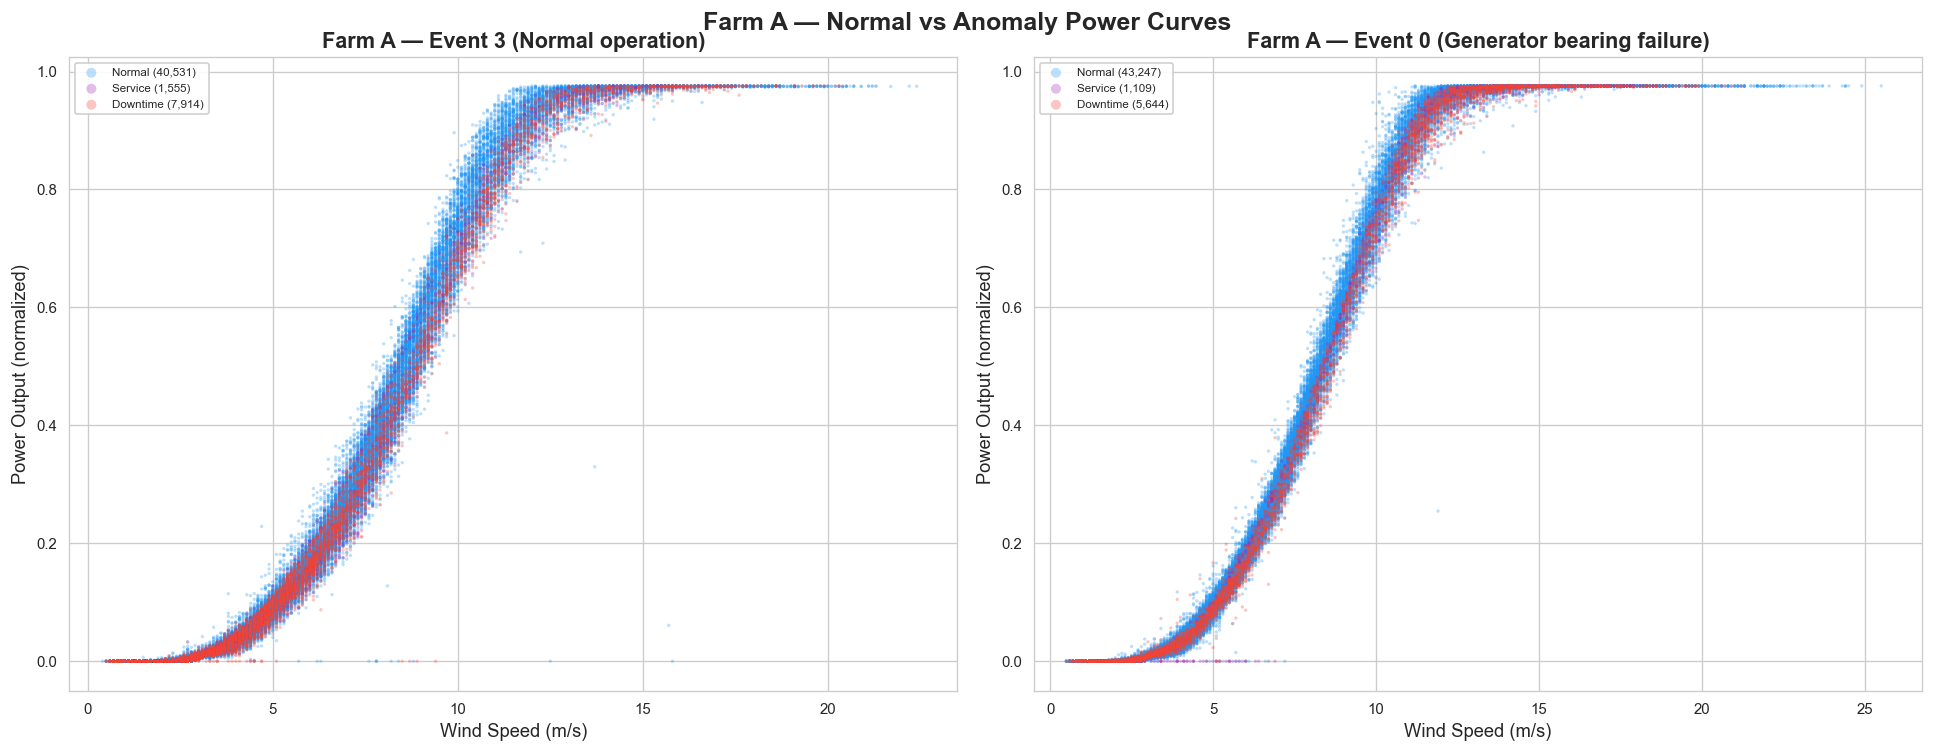

In [3]:
# Farm A: normal event 3 vs anomaly event 0 (generator bearing failure)
farm = "A"
normal_id = 3
anomaly_id = 0

df_norm = load_event(farm, normal_id)
df_anom = load_event(farm, anomaly_id)

norm_desc = get_event_description(farm, normal_id)
anom_desc = get_event_description(farm, anomaly_id)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

plot_power_curve(
    axes[0], df_norm, farm,
    f"Farm A — Event {normal_id} ({norm_desc})"
)
plot_power_curve(
    axes[1], df_anom, farm,
    f"Farm A — Event {anomaly_id} ({anom_desc})"
)

fig.suptitle("Farm A — Normal vs Anomaly Power Curves", fontsize=15, fontweight="bold", y=1.02)
fig.savefig(FIGURES_DIR / "power_curve_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'power_curve_farm_a.png'}")
plt.show()

## Farm B — Power Curves

Farm B includes Derated (status 1) and Other (status 5) operating modes in addition to Normal. The anomaly event may show more Downtime periods or derated operation that suppresses power output.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\power_curve_farm_b.png


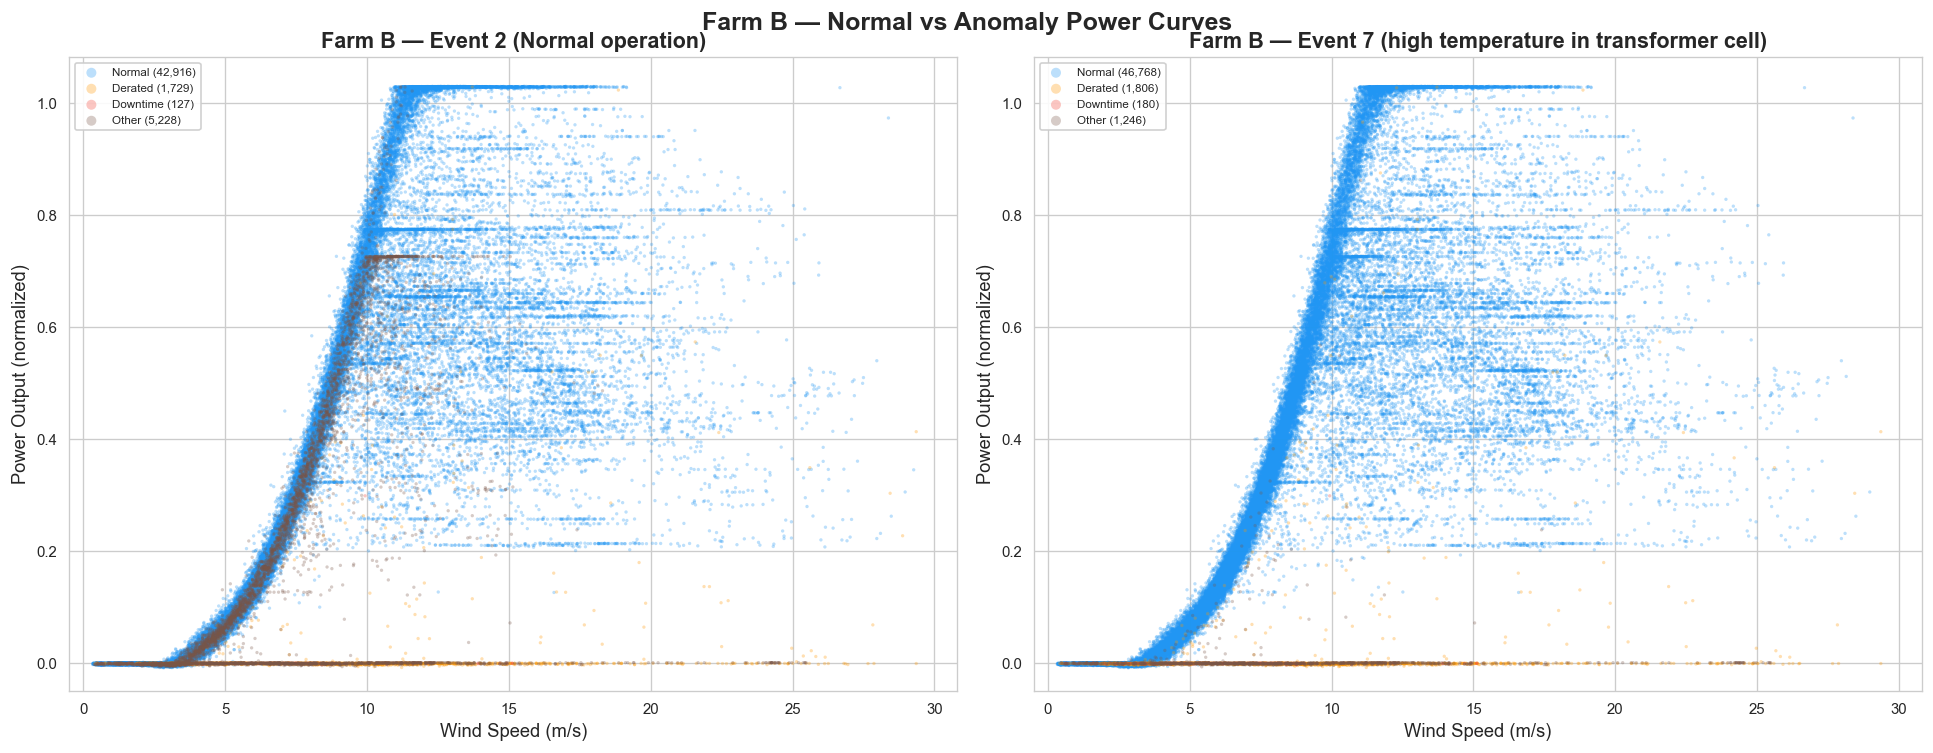

In [4]:
# Farm B: normal event 2 vs anomaly event 7
farm = "B"
normal_id = 2
anomaly_id = 7

df_norm = load_event(farm, normal_id)
df_anom = load_event(farm, anomaly_id)

norm_desc = get_event_description(farm, normal_id)
anom_desc = get_event_description(farm, anomaly_id)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

plot_power_curve(
    axes[0], df_norm, farm,
    f"Farm B — Event {normal_id} ({norm_desc})"
)
plot_power_curve(
    axes[1], df_anom, farm,
    f"Farm B — Event {anomaly_id} ({anom_desc})"
)

fig.suptitle("Farm B — Normal vs Anomaly Power Curves", fontsize=15, fontweight="bold", y=1.02)
fig.savefig(FIGURES_DIR / "power_curve_farm_b.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'power_curve_farm_b.png'}")
plt.show()

## Farm C — Power Curves

Farm C is the most heavily instrumented farm (957 features). It has the largest number of anomaly events (27). We compare a normal event against a transformer failure anomaly.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\power_curve_farm_c.png


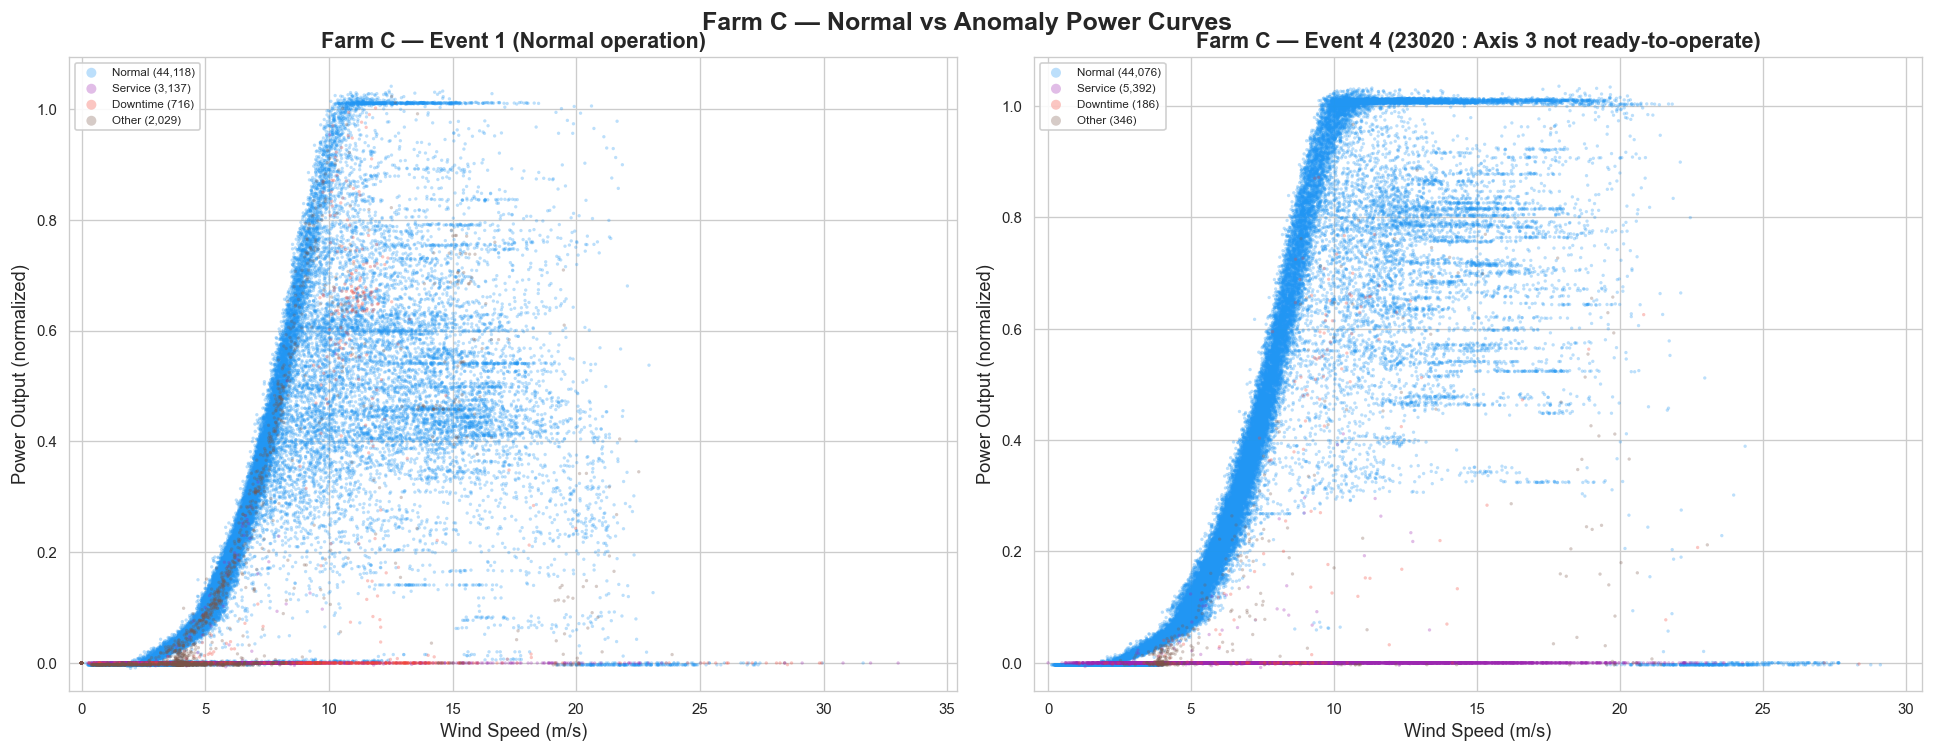

In [5]:
# Farm C: normal event 1 vs anomaly event 4
farm = "C"
normal_id = 1
anomaly_id = 4

df_norm = load_event(farm, normal_id)
df_anom = load_event(farm, anomaly_id)

norm_desc = get_event_description(farm, normal_id)
anom_desc = get_event_description(farm, anomaly_id)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

plot_power_curve(
    axes[0], df_norm, farm,
    f"Farm C — Event {normal_id} ({norm_desc})"
)
plot_power_curve(
    axes[1], df_anom, farm,
    f"Farm C — Event {anomaly_id} ({anom_desc})"
)

fig.suptitle("Farm C — Normal vs Anomaly Power Curves", fontsize=15, fontweight="bold", y=1.02)
fig.savefig(FIGURES_DIR / "power_curve_farm_c.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'power_curve_farm_c.png'}")
plt.show()

## Normal vs Anomaly Power Curve Overlay

Overlaying the power curves from a normal and anomaly event on the **same axes** makes it easy to spot whether the anomaly event exhibits a degraded or disrupted power curve. We use Farm A (simplest farm, clearest contrast between generator bearing failure and normal operation).

- **Blue** = Normal event (healthy operation)
- **Red** = Anomaly event (generator bearing failure)

If the anomaly shows points clustered at zero power during mid-to-high wind speeds, that indicates forced shutdowns or power loss during the fault period.

Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\power_curve_overlay_farm_a.png


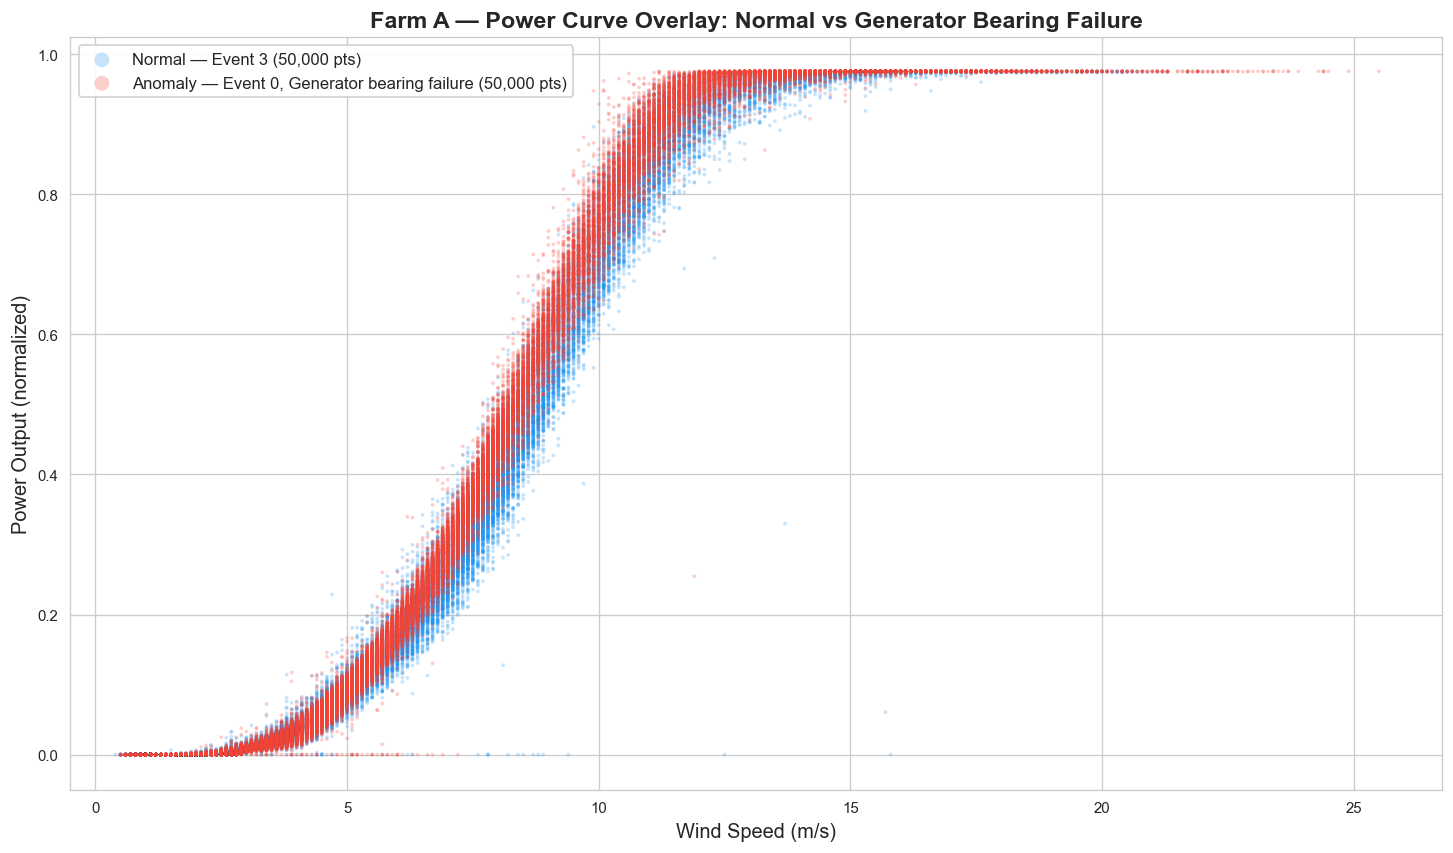

In [6]:
# Overlay: Farm A normal (event 3) vs anomaly (event 0) on same axes
farm = "A"
ws_col = POWER_CURVE_COLS[farm]["wind_speed"]
pw_col = POWER_CURVE_COLS[farm]["power"]

df_norm = load_event(farm, 3)[[ws_col, pw_col]].dropna()
df_anom = load_event(farm, 0)[[ws_col, pw_col]].dropna()

# Sample both to MAX_POINTS
if len(df_norm) > MAX_POINTS:
    df_norm = df_norm.sample(n=MAX_POINTS, random_state=42)
if len(df_anom) > MAX_POINTS:
    df_anom = df_anom.sample(n=MAX_POINTS, random_state=42)

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

# Plot normal first (behind), then anomaly on top
ax.scatter(
    df_norm[ws_col], df_norm[pw_col],
    c="#2196F3", s=5, alpha=0.25, edgecolors="none",
    label=f"Normal — Event 3 ({len(df_norm):,} pts)", rasterized=True,
)
ax.scatter(
    df_anom[ws_col], df_anom[pw_col],
    c="#F44336", s=5, alpha=0.25, edgecolors="none",
    label=f"Anomaly — Event 0, Generator bearing failure ({len(df_anom):,} pts)", rasterized=True,
)

ax.set_xlabel("Wind Speed (m/s)", fontsize=12)
ax.set_ylabel("Power Output (normalized)", fontsize=12)
ax.set_title("Farm A — Power Curve Overlay: Normal vs Generator Bearing Failure",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, markerscale=4, framealpha=0.9)
ax.set_xlim(left=-0.5)
ax.set_ylim(bottom=-0.05)

fig.savefig(FIGURES_DIR / "power_curve_overlay_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'power_curve_overlay_farm_a.png'}")
plt.show()

## Status Type Distribution — Anomaly vs Normal Events

If anomaly events truly represent fault periods, we'd expect them to have a higher proportion of non-normal status types (Downtime, Service, Derated) compared to normal events. This bar chart aggregates across **all events** in each farm to validate that assumption.

In [7]:
# Aggregate status type proportions across all events per farm
records = []

for farm in ["A", "B", "C"]:
    for label in ["normal", "anomaly"]:
        eids = get_event_ids(farm, label)
        # Sample up to 5 events per category to keep load time reasonable
        for eid in eids[:5]:
            df = load_event(farm, eid)
            counts = df["status_type_id"].value_counts(normalize=True)
            for status_id, proportion in counts.items():
                records.append({
                    "farm": f"Farm {farm}",
                    "event_label": label.capitalize(),
                    "status_type_id": int(status_id),
                    "status_name": STATUS_LABELS.get(int(status_id), f"Status {status_id}"),
                    "proportion": proportion,
                })

status_df = pd.DataFrame(records)

# Average proportions across events within each (farm, label, status) group
avg_status = (
    status_df
    .groupby(["farm", "event_label", "status_type_id", "status_name"])["proportion"]
    .mean()
    .reset_index()
)

print(f"Aggregated status distributions from {len(status_df)} event-status records.")
print(f"Farms x labels x statuses = {len(avg_status)} rows.")
avg_status.head(10)

Aggregated status distributions from 110 event-status records.
Farms x labels x statuses = 22 rows.


,farm,event_label,status_type_id,status_name,proportion
0,Farm A,Anomaly,0,Normal,0.841674
1,Farm A,Anomaly,3,Service,0.024527
2,Farm A,Anomaly,4,Downtime,0.133799
3,Farm A,Normal,0,Normal,0.866243
4,Farm A,Normal,3,Service,0.024764
5,Farm A,Normal,4,Downtime,0.108993
6,Farm B,Anomaly,0,Normal,0.904696
7,Farm B,Anomaly,1,Derated,0.061977
8,Farm B,Anomaly,4,Downtime,0.003627
9,Farm B,Anomaly,5,Other,0.029701


Saved: D:\Personal Projects\Enbridge Case Compettion\outputs\figures\power_curve_status_distribution.png


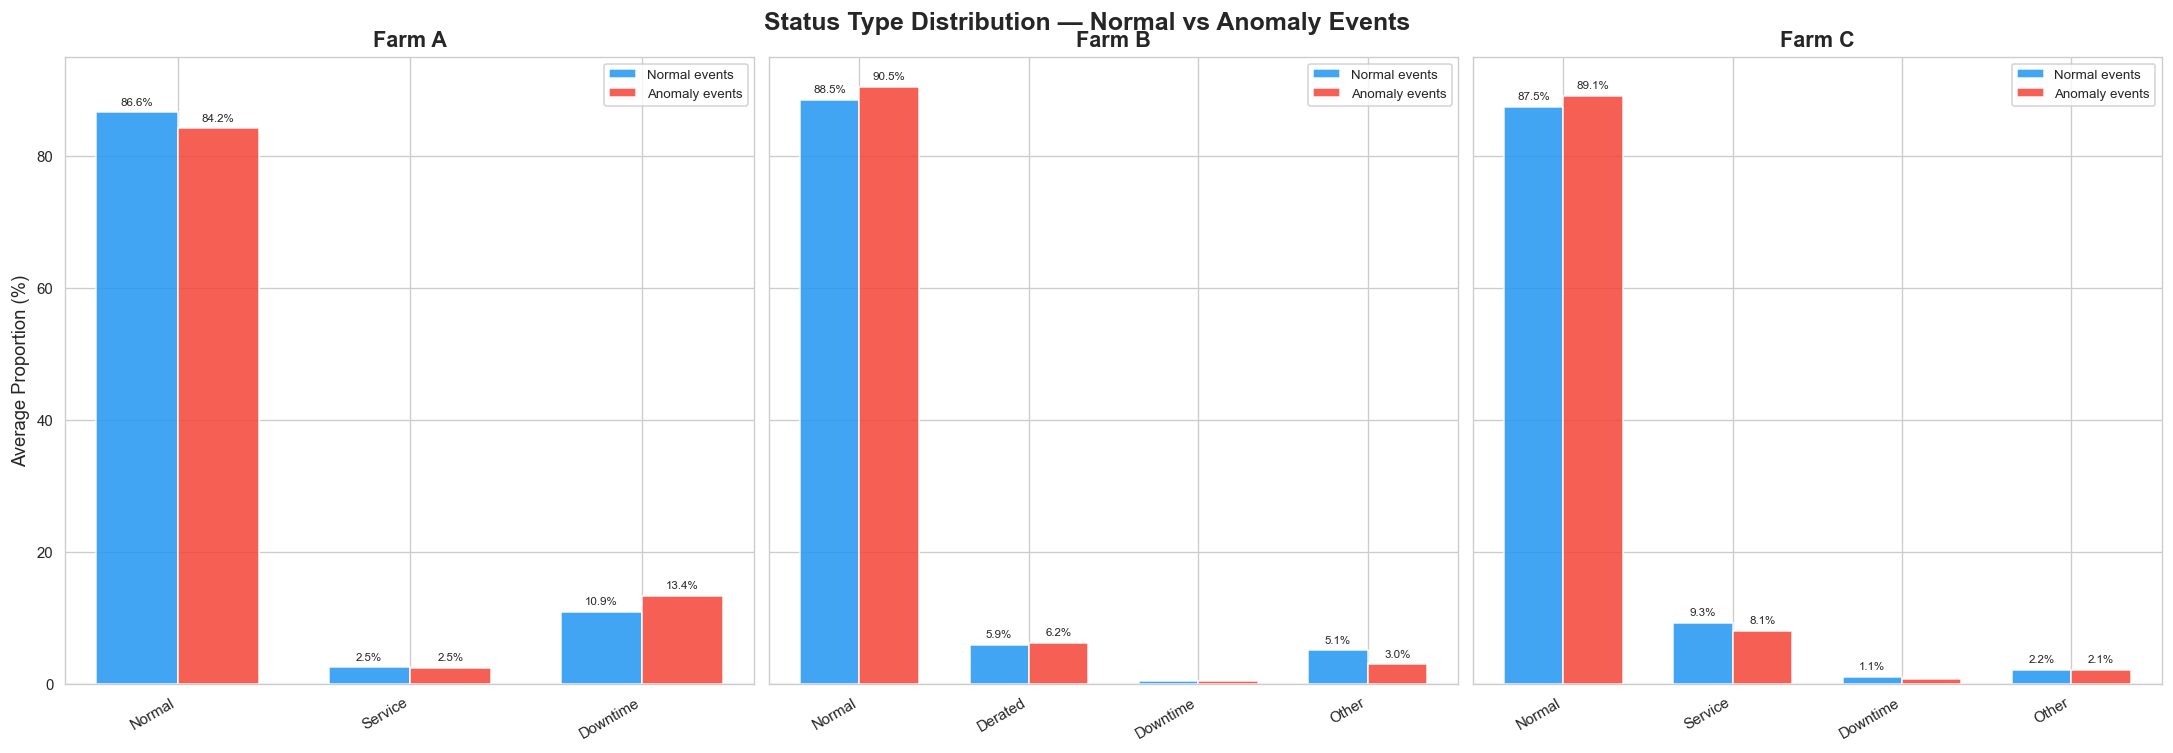

In [8]:
# Grouped bar chart: status type proportions — Normal vs Anomaly, per farm
farms = ["Farm A", "Farm B", "Farm C"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True, sharey=True)

for i, farm_name in enumerate(farms):
    ax = axes[i]
    farm_data = avg_status[avg_status["farm"] == farm_name].copy()
    
    # Pivot to get Normal vs Anomaly columns for each status
    pivot = farm_data.pivot_table(
        index="status_name", columns="event_label", values="proportion", fill_value=0
    )
    
    # Ensure both columns exist
    for col in ["Normal", "Anomaly"]:
        if col not in pivot.columns:
            pivot[col] = 0.0
    
    # Sort by status_type_id order
    status_order = [STATUS_LABELS[s] for s in sorted(STATUS_LABELS.keys()) if STATUS_LABELS[s] in pivot.index]
    pivot = pivot.reindex(status_order)
    
    x = np.arange(len(pivot))
    width = 0.35
    
    bars_norm = ax.bar(x - width / 2, pivot["Normal"] * 100, width,
                       label="Normal events", color="#2196F3", alpha=0.85, edgecolor="white")
    bars_anom = ax.bar(x + width / 2, pivot["Anomaly"] * 100, width,
                       label="Anomaly events", color="#F44336", alpha=0.85, edgecolor="white")
    
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=30, ha="right", fontsize=9)
    ax.set_title(farm_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    
    if i == 0:
        ax.set_ylabel("Average Proportion (%)", fontsize=11)
    
    ax.legend(fontsize=8, loc="upper right")
    
    # Add value labels on bars
    for bar in list(bars_norm) + list(bars_anom):
        height = bar.get_height()
        if height > 1:  # only label bars > 1%
            ax.annotate(f"{height:.1f}%",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7)

fig.suptitle("Status Type Distribution — Normal vs Anomaly Events",
             fontsize=15, fontweight="bold", y=1.02)

fig.savefig(FIGURES_DIR / "power_curve_status_distribution.png", bbox_inches="tight", dpi=150)
print(f"Saved: {FIGURES_DIR / 'power_curve_status_distribution.png'}")
plt.show()

In [9]:
# Summary of all saved figures from this notebook
print("=" * 60)
print("All figures saved to outputs/figures/:")
print("=" * 60)
for f in sorted(FIGURES_DIR.glob("power_curve_*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:45s} ({size_kb:.0f} KB)")

All figures saved to outputs/figures/:
  power_curve_farm_a.png                        (375 KB)
  power_curve_farm_b.png                        (853 KB)
  power_curve_farm_c.png                        (724 KB)
  power_curve_overlay_farm_a.png                (316 KB)
  power_curve_status_distribution.png           (73 KB)


## Key Observations

*(Fill in after reviewing the plots above)*

**Power curve shape:**
- 
- 

**Normal vs anomaly differences:**
- 
- 

**Status type patterns:**
- 
- 

**Implications for Phase 3 (Normal Behavior Models):**
- 
- 